## Load in packages and data

In [1]:
import numpy as np
import pandas as pd
# import geopandas as gpd
import matplotlib.pyplot as plt
import matsim_output_analysis_experienced as moa
import operator

In [2]:
# df_pl = pd.read_csv(r"170426_plans_TE_baseline.csv") #this is the 2040 baseline plans
# df_ex = pd.read_csv(r"170426_plans_TE_experienced_baseline.csv") #this is the 2040 baseline plans

In [46]:
# df_pl = pd.read_csv(r"140426_plans_te.csv") 
# df_ex = pd.read_csv(r"140426_experienced_plans_te.csv") 
df_pl = pd.read_csv(r"220426_plans_alternates.csv") 
df_ex = pd.read_csv(r"220426_experienced_plans_alternates.csv") 
df_pl = df_pl[["id", "subpopulation" , "selected plan activity_type_or_mode"]]
df_pl.columns = ["id", "subpopulation" , "planned plan activity_type_or_mode"]
df = pd.merge(df_pl, df_ex, how = "outer", on="id")

# #the following is only needed for handling experienced plans
# df["stuck_bool"] =  (df["selected plan activity_type_or_mode"] != df["planned plan activity_type_or_mode"]).astype(int) #so the bool tells us: 1 if stuck, 0 if not stuck

In [47]:
df.iloc[6]["selected plan activity_type_or_mode"]

'home; walk; pt interaction; bus; pt interaction; walk; shop; walk; pt interaction; rail; pt interaction; walk; pt interaction; rail; pt interaction; walk; pt interaction; bus; pt interaction; walk; work; walk; pt interaction'

In [4]:
# df_sample = df.sample(20000)
# df_sample.to_csv("170426_baseline_sample.csv")

In [5]:
# df_init = pd.read_csv("170426_baseline_sample.csv")

In [6]:
# df_init = df_init[~df_init["subpopulation"].isin(["hgv","lgv","airport", "lgv_ev"])] 
# df_init = df_init[~df_init["id"].isin(["empty_plan"])] #choose only the actual people

In [7]:
# count_na_routes =  df_init["selected plan routes"].isna().sum()
# print(count_na_routes)

In [8]:
# # Rows WITH NaN in "routes" -> those with NO TRIPS 
# #TODO: handle these!!
# nan_rows = df_init[df_init["selected plan routes"].isna()]

# # Rows WITHOUT NaN (cleaned DataFrame)
# df = df_init[df_init["selected plan routes"].notna()]

In [9]:
df["stuck_bool"] =  (df["selected plan activity_type_or_mode"] != df["planned plan activity_type_or_mode"]).astype(int) #so the bool tells us: 1 if stuck, 0 if not stuck

In [10]:
#turn plan summaries into lists instead of long strings
df['selected plan activity_type_or_mode'] = df['selected plan activity_type_or_mode'].str.split('; ')
df['selected plan distance_travelled'] = df['selected plan distance_travelled'].str.split('; ')
df['selected plan duration'] = df['selected plan duration'].str.split('; ')
df['selected plan location'] = df['selected plan location'].str.split('; ')
df['selected plan routes'] = df['selected plan routes'].str.split('; ')
df['selected plan boardingTime'] = df['selected plan boardingTime'].str.split('; ')

<!-- ## Remove "pt interaction" terms and all corresponding columns -->

In [11]:
#extract the indices of where pt interaction happens
df['selected plan ptinteraction_indices'] = df['selected plan activity_type_or_mode'].apply(moa.get_ptinteraction_index)

In [12]:
#remove the pt interaction activities
df['selected plan activity_type_or_mode'] = df.apply(lambda row: moa.remove_ptinteraction(row['selected plan ptinteraction_indices'], row['selected plan activity_type_or_mode']), axis=1)

In [13]:
#remove the correspinding pt interaction durations
df['selected plan duration'] = df.apply(lambda row: moa.remove_ptinteraction(row['selected plan ptinteraction_indices'], row['selected plan duration']), axis=1)

In [14]:
#remove the correspinding pt interaction locations
df['selected plan location'] = df.apply(lambda row: moa.remove_ptinteraction(row['selected plan ptinteraction_indices'], row['selected plan location']), axis=1)

In [15]:
#remove the correspinding pt interaction distance travelled
df['selected plan distance_travelled'] = df.apply(lambda row: moa.remove_ptinteraction(row['selected plan ptinteraction_indices'], row['selected plan distance_travelled']), axis=1)

In [16]:
#remove the correspinding pt interaction distance travelled
df['selected plan boardingTime'] = df.apply(lambda row: moa.remove_ptinteraction(row['selected plan ptinteraction_indices'], row['selected plan boardingTime']), axis=1)

In [17]:
#remove the correspinding pt interaction distance travelled
df['selected plan routes'] = df.apply(lambda row: moa.remove_ptinteraction(row['selected plan ptinteraction_indices'], row['selected plan routes']), axis=1)

In [18]:
#clean  up table and remove indices
df = df.drop(["selected plan ptinteraction_indices","unselected plan (1) activity_type_or_mode", "unselected plan (1) distance_travelled", "unselected plan (1) duration", "unselected plan (1) location", "unselected plan (1) routes", "unselected plan (1) number", "unselected plan (1) utility",
              "unselected plan (2) activity_type_or_mode", "unselected plan (2) distance_travelled", "unselected plan (2) duration", "unselected plan (2) location",  "unselected plan (2) number", "unselected plan (2) utility",
              "unselected plan (3) activity_type_or_mode", "unselected plan (3) distance_travelled", "unselected plan (3) duration", "unselected plan (3) location",  "unselected plan (3) number", "unselected plan (3) utility",
              "unselected plan (4) activity_type_or_mode", "unselected plan (4) distance_travelled", "unselected plan (4) duration", "unselected plan (4) location", "unselected plan (4) number", "unselected plan (4) utility"], axis=1)

## Calculating utility components

Get activity start and end times, and highlight any "stuck" agents

In [19]:
def update_last_element(lst, stuck_bool):
    if isinstance(lst, list) and len(lst) > 0 and stuck_bool==0:
        lst[-1] = "24:00:00"
    return lst

df['selected plan duration'] =  df.apply(lambda row: update_last_element(row['selected plan duration'], row['stuck_bool']), axis=1)

In [20]:
df["legs_indices"] = df["selected plan activity_type_or_mode"].apply(moa.get_trips_indices_only)
df["activities_indices"] = df["selected plan activity_type_or_mode"].apply(moa.get_activities_indices_only)
df["selected plan leg_durations"] = df.apply(lambda row: moa.get_trips_duration_or_mode(row["legs_indices"], row["selected plan duration"]), axis=1)
df["selected plan activity_durations"] = df.apply(lambda row: moa.get_trips_duration_or_mode(row["activities_indices"], row["selected plan duration"]), axis=1)


In [21]:
df[["activity_starts", "activity_ends","stuck_index"]] = df.apply(lambda row: moa.get_activity_timings(row["activities_indices"], row["selected plan duration"], row["selected plan activity_type_or_mode"], row["stuck_bool"]), axis=1, result_type="expand")

In [22]:
df["calculated_activity_durations"] = df.apply(lambda row: moa.get_activity_durations(row["activity_starts"], row["activity_ends"], row["selected plan activity_type_or_mode"], row["stuck_index"], row["stuck_bool"]), axis=1)

In [23]:
df["selected plan activities"] = df.apply(lambda row: moa.get_activities(row["selected plan activity_type_or_mode"], row["activities_indices"], row["stuck_index"]), axis=1) #this needs to account for stuckness

Now can call activity utility function as normal, BUT ADD IN PENALTY FOR NEGATIVE OVERNIGHT DURATION

In [24]:
df["calculated_activity_u"] =  df.apply(lambda row: moa.calculate_activity_utility(row["stuck_bool"], row["selected plan activity_type_or_mode"], row["activities_indices"], row["stuck_index"], row["calculated_activity_durations"]), axis=1)

Travel utility

In [25]:
#do the tolls
import xmltodict
import pprint

with open(r"C:\Users\maria\Documents\matsim_analysis\data\2040_do_minimum_40wfh_rerun_10pc_20250306\output_toll.xml", 'r', encoding='utf-8') as file:
    my_xml = file.read()
output_tolls = xmltodict.parse(my_xml)
tolls = output_tolls["roadpricing"]["links"]["link"]
tolls2  = {item['@id']: item['cost']['@amount'] for item in tolls}

In [26]:
df["calculated_travel_u"] = df.apply(lambda row: moa.calculate_travel_utility(row["id"], row["selected plan activity_type_or_mode"], row["selected plan duration"], row["selected plan distance_travelled"],
                            row["activities_indices"], row["subpopulation"], row["selected plan boardingTime"], 
                            row["activity_ends"], row["selected plan routes"], tolls2, row["stuck_index"]), axis=1)

would be tolls
agent_0
would be tolls
agent_0
would be tolls
agent_0
would be tolls
agent_0
would be tolls
agent_0
would be tolls
agent_0
would be tolls
agent_0
would be tolls
agent_0
would be tolls
agent_0
would be tolls
agent_0
would be tolls
agent_0
would be tolls
agent_1
would be tolls
agent_1
would be tolls
agent_1
would be tolls
agent_1
would be tolls
agent_1
would be tolls
agent_1
would be tolls
agent_1
would be tolls
agent_1
would be tolls
agent_1
would be tolls
agent_1
would be tolls
agent_1
would be tolls
agent_1
would be tolls
agent_1
would be tolls
agent_1
would be tolls
agent_1
would be tolls
agent_1
would be tolls
agent_1
would be tolls
agent_10
would be tolls
agent_10
would be tolls
agent_10
would be tolls
agent_10
would be tolls
agent_10
would be tolls
agent_10
would be tolls
agent_10
would be tolls
agent_10
would be tolls
agent_10
would be tolls
agent_10
would be tolls
agent_10
would be tolls
agent_11
would be tolls
agent_11
would be tolls
agent_11
would be tolls
agent

In [27]:
moa.calculate_travel_utility(df.iloc[62]["id"], df.iloc[62]["selected plan activity_type_or_mode"], df.iloc[62]["selected plan duration"], df.iloc[62]["selected plan distance_travelled"],
                            df.iloc[62]["activities_indices"], df.iloc[62]["subpopulation"], df.iloc[62]["selected plan boardingTime"], 
                            df.iloc[62]["activity_ends"], df.iloc[62]["selected plan routes"], tolls2, df.iloc[62]["stuck_index"])

would be tolls
agent_65
would be tolls
agent_65
would be tolls
agent_65
would be tolls
agent_65
would be tolls
agent_65
would be tolls
agent_65
would be tolls
agent_65
would be tolls
agent_65
would be tolls
agent_65
would be tolls
agent_65
would be tolls
agent_65
would be tolls
agent_65
would be tolls
agent_65
would be tolls
agent_65


[np.float64(-2.702061045743646),
 np.float64(-5.4571424541872675),
 np.float64(-16.87822551707591),
 np.float64(-13.096606138501034)]

In [28]:
df["calculated_travel_u_2"] = df.apply(lambda row: moa.calculate_travel_utility(row["id"], row["selected plan activity_type_or_mode"], row["selected plan duration"], row["selected plan distance_travelled"],
                            row["activities_indices"], row["subpopulation"], row["selected plan boardingTime"], 
                            row["activity_ends"], row["selected plan routes"], tolls2, row["stuck_index"]), axis=1)

would be tolls
agent_0
would be tolls
agent_0
would be tolls
agent_0
would be tolls
agent_0
would be tolls
agent_0
would be tolls
agent_0
would be tolls
agent_0
would be tolls
agent_0
would be tolls
agent_0
would be tolls
agent_0
would be tolls
agent_0
would be tolls
agent_1
would be tolls
agent_1
would be tolls
agent_1
would be tolls
agent_1
would be tolls
agent_1
would be tolls
agent_1
would be tolls
agent_1
would be tolls
agent_1
would be tolls
agent_1
would be tolls
agent_1
would be tolls
agent_1
would be tolls
agent_1
would be tolls
agent_1
would be tolls
agent_1
would be tolls
agent_1
would be tolls
agent_1
would be tolls
agent_1
would be tolls
agent_10
would be tolls
agent_10
would be tolls
agent_10
would be tolls
agent_10
would be tolls
agent_10
would be tolls
agent_10
would be tolls
agent_10
would be tolls
agent_10
would be tolls
agent_10
would be tolls
agent_10
would be tolls
agent_10
would be tolls
agent_11
would be tolls
agent_11
would be tolls
agent_11
would be tolls
agent

In [29]:
df["calculated_penalty_u"] = df.apply(lambda row: moa.calculate_stuck_penalty(row["selected plan activity_type_or_mode"], row["stuck_index"]), axis=1)

Sum travel, activity, and penalty to get overall score

In [30]:
df["total_travel_u"] = df.apply(lambda row: sum(row["calculated_travel_u_2"]), axis=1)

In [31]:
df["total_activity_u"] = df.apply(lambda row: sum(row["calculated_activity_u"]), axis=1)

In [32]:
df["calculated_total_u"] = df["total_travel_u"]+df["total_activity_u"]+df["calculated_penalty_u"]

(array([ 1.,  0.,  1.,  3., 10., 13., 19., 12., 23., 18.]),
 array([-27.73075929, -13.03201809,   1.66672311,  16.36546432,
         31.06420552,  45.76294672,  60.46168793,  75.16042913,
         89.85917033, 104.55791154, 119.25665274]),
 <BarContainer object of 10 artists>)

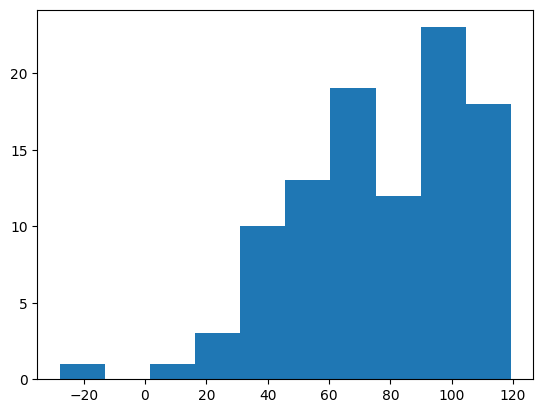

In [33]:
plt.hist(df["calculated_total_u"])

In [34]:
df["diff"] = abs(df["selected plan utility"] - df["calculated_total_u"])

Text(0, 0.5, 'Maria calculated utility')

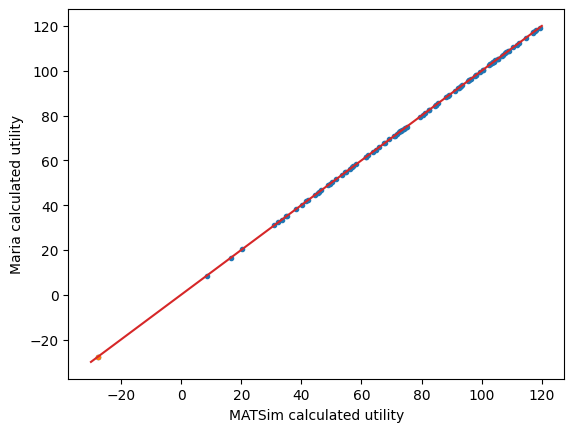

In [35]:
df2 = df[df["stuck_bool"]==0]
df3 = df[df["stuck_bool"]==1]
df4 = df[df["diff"]>100]

df5 = df[df["calculated_travel_u"]==df["calculated_travel_u_2"]]
df6 = df[df["calculated_travel_u"]!=df["calculated_travel_u_2"]]

plt.plot(df["selected plan utility"], df["calculated_total_u"], ".", alpha=1)
plt.plot(df3["selected plan utility"], df3["calculated_total_u"], ".")
plt.plot(df4["selected plan utility"], df4["calculated_total_u"], ".")
# plt.legend(["no tolls", "tolls"])
# plt.plot(df4["selected plan utility"], df4["calculated_total_u"], ".")
x = [-30,50, 100, 120]
# y1 = [i*1.1 for i in x ]
# y2 = [i*0.9 for i in x ]
# y3 = [i+85 for i in x ]
plt.plot(x, x)
# plt.plot(x, y3)
plt.xlabel("MATSim calculated utility")
plt.ylabel("Maria calculated utility")
# plt.plot(x, y1)
# plt.plot(x, y2)
# plt.plot(x, y3)
# plt.xlim(0,200)
# plt.ylim(0,200)

In [36]:
diffs = list(df["diff"])
calcutils = list(df["calculated_total_u"])
j=0
for i in range(len(diffs)):
    if abs(diffs[i]>1) :
    # if calcutils[i] < -600:
        print("i: "+str(i))
        print("id: "+str(df.iloc[i]["id"]))
        print(df.iloc[i]["subpopulation"])
        print(df.iloc[i]["diff"])
        j+=1
print(j)

0


In [45]:
df.iloc[6]["stuck_bool"]

np.int64(1)

In [38]:
df.iloc[44]["selected plan routes"]

['N/A',
 'N/A',
 '{"transitRouteId":"7708_2","boardingTime":"07:41:00","transitLineId":"7708","accessFacilityId":"5221377948179671947","egressFacilityId":"5221366454447747335"}',
 'N/A',
 '{"transitRouteId":"7714_0","boardingTime":"07:54:00","transitLineId":"7714","accessFacilityId":"5221366454447747335","egressFacilityId":"5221366206542936931"}',
 'N/A',
 'N/A',
 '5221366208363264957_5221366208436072103 5663 7740 4055 5221366208882490817_5221366181603398929 5221366181603398929_5221366181807161407 10662 5070 5221366182013223007_5221366182092174279 5221366182092174279_5221366182178686101 9354 5524 5221366178309587079_5221366178252504153 8488 1393 10171 5221366453254402467_5221366453370993615 5221366453370993615_5221366453561157931 1255 5984 4886 10221 5660 4734 5452 1070 6816 5221366459341604967_5221366458964660921 10357 9800 5221366468371938159_5221366469047159579 10573 5221366468619800209_5221366465353563193 5221366465353563193_5221366578767076531 2790 5221366579269874961_522136641794

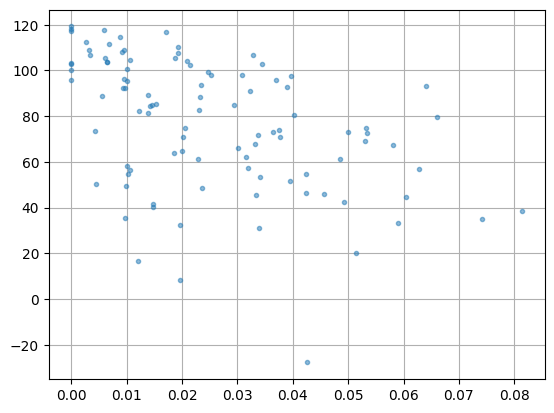

In [39]:
plt.plot(df["diff"], df["calculated_total_u"], ".", alpha=0.5)
# plt.xlim([10,50])
plt.grid()

(array([18., 23., 17.,  8., 15.,  5.,  6.,  5.,  1.,  2.]),
 array([0.        , 0.00814594, 0.01629188, 0.02443782, 0.03258376,
        0.0407297 , 0.04887564, 0.05702158, 0.06516752, 0.07331346,
        0.0814594 ]),
 <BarContainer object of 10 artists>)

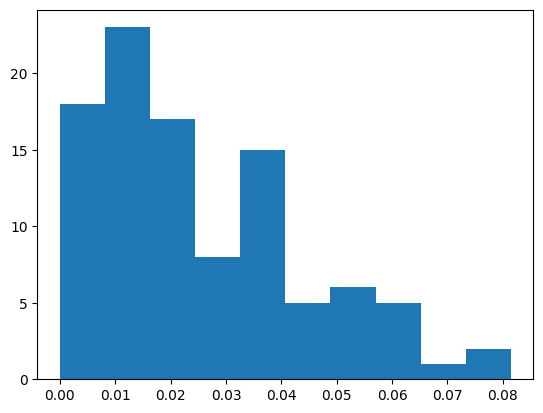

In [40]:
plt.hist(df["diff"])